In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re 
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, BatchNormalization, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



# Load Dataset

In [2]:
def load_imdb(data_dir="aclImdb"):
    data = []
    
    for sentiment in ["pos","neg"]:
        folder = os.path.join(data_dir, "train", sentiment)
        for filename in os.listdir(folder):
            if filename.endswith(".txt"):
                with open(os.path.join(folder, filename), 'r', encoding='utf-8') as file:
                    text = file.read()
                data.append({"review": text, "sentiment": sentiment, "source":"train"})
    
    df = pd.DataFrame(data)
    
    df ['label'] = df['sentiment'].map({'pos': 1, 'neg': 0})
    
    return df

df = load_imdb()
print(f"Total Reviews: {len(df)}")
print(f"Positive: {len(df[df['label']==1])}, Negative: {len(df[df['label']==0])}")
print(df.head())

Total Reviews: 25000
Positive: 12500, Negative: 12500
                                              review sentiment source  label
0  Bromwell High is a cartoon comedy. It ran at t...       pos  train      1
1  Homelessness (or Houselessness as George Carli...       pos  train      1
2  Brilliant over-acting by Lesley Ann Warren. Be...       pos  train      1
3  This is easily the most underrated film inn th...       pos  train      1
4  This is not the typical Mel Brooks film. It wa...       pos  train      1


# Data Cleaning

In [3]:
def clean_text(text):
    
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text) 
    # Stops at > then deletes the the whole tag.
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    
    # Remove special characters and numbers (Ex: !!! 123)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra whitespace (Ex: hi    name   potato turns into hi name potato)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize and remove stopwords
    tokens = word_tokenize(text)
    # Remove stop words (Ex: i, this, it ,was ....)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatize
    # Reduces words to their base form (Ex: better -> good running -> run. )
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

# Test cleaning
sample_text = df['review'].iloc[0]
print("Original:", sample_text[:200])
print("\nCleaned:", clean_text(sample_text[:200]))


Original: Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's 

Cleaned: bromwell high cartoon comedy ran time program school life teacher year teaching profession lead believe bromwell high


# Preprocessing

In [4]:
# Used for RNN, LSTM, and GRU.
def process_data(df, max_words = 5000, max_len = 100 ):
    print("Cleaning...")
    df['cleaned_review'] = df['review'].apply(clean_text)
    
    # Tokenizer
    # Keeps the 5000 most common words rest becomes Out Of Vocabulary (OOV)
    # 5000 words to reduce model size and training time.
    tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
    tokenizer.fit_on_texts(df['cleaned_review'])
    
    # Conver to sequences to be used in models.    
    sequences = tokenizer.texts_to_sequences(df['cleaned_review'])
    
    # Neural network takes fixed sized inputs. Padding needed to reach said size. 
    # Ex: if review 1 is 2 words and review 2 is 5 words,
    # then in review 1, 0 zeroes will be added for both to be equal in length.
    X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    y = df['label'].values
    
    # Split data (60 train 20 val 20 test) Subject to change.
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  
    )
    
    vocab_size = len(tokenizer.word_index) + 1
    
    print(f" Vocabulary Size: {vocab_size}")
    print(f" Train: {X_train.shape} \n Val: {X_val.shape} \n Test: {X_test.shape}")

    return X_train, X_val, X_test, y_train, y_val, y_test, vocab_size, tokenizer, df

X_train, X_val, X_test, y_train, y_val, y_test, vocab_size, tokenizer, df = process_data(df)

Cleaning...
 Vocabulary Size: 65481
 Train: (15000, 100) 
 Val: (5000, 100) 
 Test: (5000, 100)


# EDA


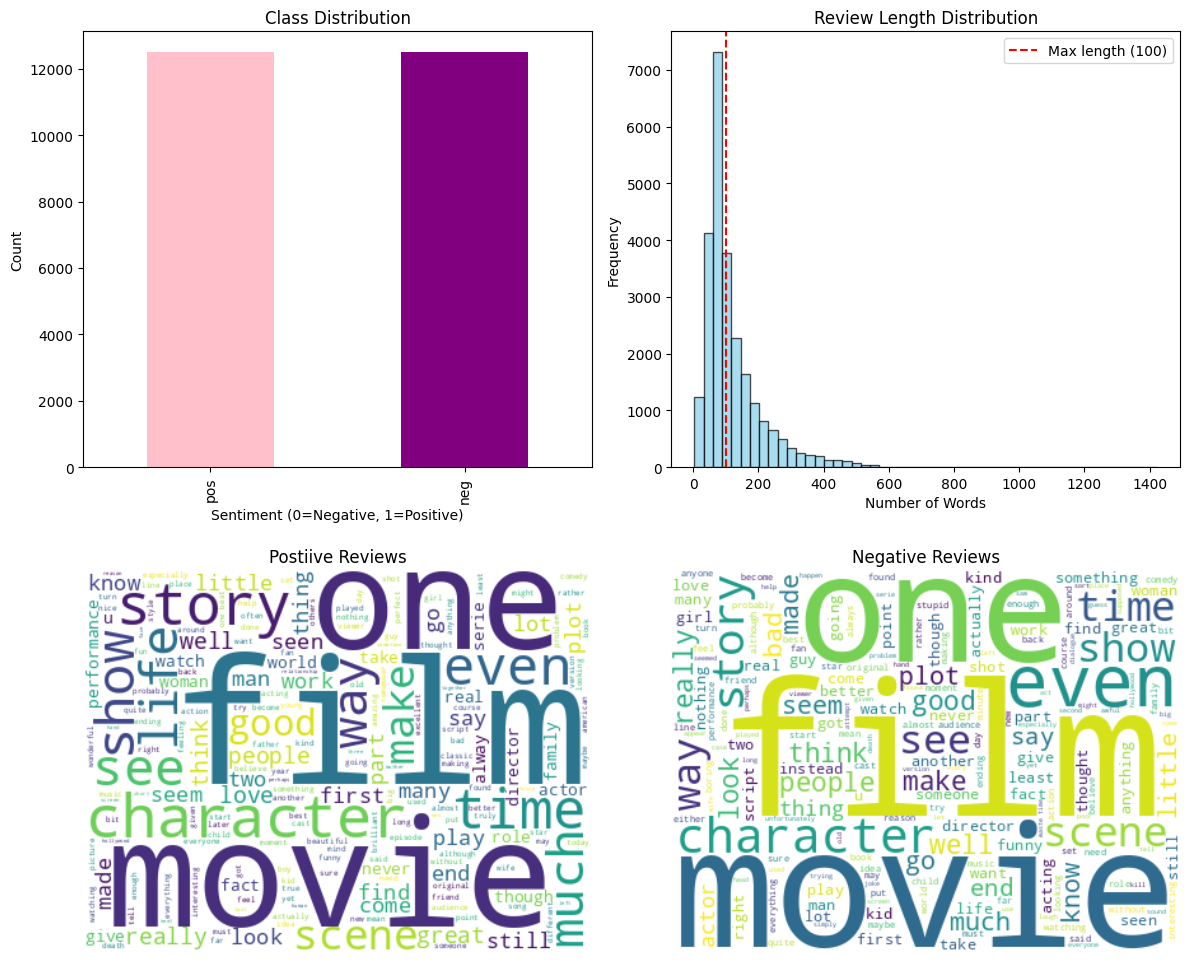

In [5]:
from wordcloud import WordCloud
if "cleaned_review" not in df.columns:
    df["cleaned_review"] = df["review"].apply(clean_text)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Class distribution
ax1 = axes[0,0]
df['sentiment'].value_counts().plot(kind='bar', ax =ax1, color=['pink','purple'])
ax1.set_title('Class Distribution')
ax1.set_xlabel('Sentiment (0=Negative, 1=Positive)')
ax1.set_ylabel('Count')

# Review Length Distribution
ax2 = axes[0,1]
review_lengths = df['cleaned_review'].apply(lambda x: len(x.split()))
ax2.hist(review_lengths, bins=50, alpha =0.7, color="skyblue", edgecolor='black')
ax2.axvline(x=100, color='red', linestyle='--', label='Max length (100)')
ax2.set_title('Review Length Distribution')
ax2.set_xlabel('Number of Words')
ax2.set_ylabel('Frequency')
ax2.legend()

# Word Cloud (Visual representation of text data)
# Positive Reviews
ax3 = axes[1,0]
positive_text = " ".join(df[df['label']==1]['cleaned_review'])
wc_pos = WordCloud(width=400, height=300, background_color='white').generate(positive_text)
ax3.imshow(wc_pos, interpolation = 'bilinear')
ax3.set_title("Postiive Reviews")
ax3.axis('off')

# Negative Reviews
ax4 = axes[1,1]
negative_text = " ".join(df[df['label']==0]['cleaned_review'])
wc_neg = WordCloud(width=400, height=300, background_color='white').generate(negative_text)
ax4.imshow(wc_neg, interpolation = 'bilinear')
ax4.set_title("Negative Reviews")
ax4.axis('off')

plt.tight_layout()
plt.show()

# Model Building

In [6]:
# Models were overfitting
# Attempts to fix: 
# Increase dropout
# Reduce number of units
# Reduce batch size.

def build_rnn_model(vocab_size, embedding_dim=64, max_len=100): 
    # LAYERS
    # 1 Input
    # 1 Embedding Layer
    # 3 Hidden Layers (2 Simple RNNS 1 Dense) 
    # 1 Output
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_len),
        BatchNormalization(),
        SimpleRNN(32, return_sequences=True),
        Dropout(0.5),
        BatchNormalization(),
        SimpleRNN(16),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def build_lstm_model(vocab_size, embedding_dim=64, max_len=100):
    # LAYERS
    # 1 Input
    # 1 Embedding Layer
    # 3 Hidden Layers (2 LSTM 1 Dense)
    # 1 Output
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_len),
        BatchNormalization(),
        LSTM(32, return_sequences=True),
        Dropout(0.5),
        BatchNormalization(),
        LSTM(16),
        Dropout(0.5),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def build_gru_model(vocab_size, embedding_dim=64, max_len=100):
    # LAYERS
    # 1 Input
    # 1 Embedding Layer
    # 3 Hidden Layers (2 GRU 1 Dense)
    # 1 Output
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_len),
        BatchNormalization(),
        GRU(32, return_sequences=True),
        Dropout(0.5),
        BatchNormalization(),
        GRU(16),
        Dropout(0.5),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


def build_gru_attention_simple(vocab_size, embedding_dim=64, max_len=100):
    # LAYERS
    # 1 Input
    # 1 Embedding
    # 3 Hidden Layers (1 GRU 1 Attention 1 Context Vector)
    # 1 Output 
    inputs = tf.keras.layers.Input(shape=(max_len,)) 
    
    # Embedding
    x = tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    
    # GRU layer
    gru_out = tf.keras.layers.GRU(32, return_sequences=True, dropout=0.5)(x)
    
    # Attention mechanism
    attention = tf.keras.layers.Dense(1, activation='tanh')(gru_out)  # Score each timestep
    attention = tf.keras.layers.Flatten()(attention)
    attention = tf.keras.layers.Activation('softmax')(attention)  # Attention weights
    attention = tf.keras.layers.RepeatVector(32)(attention)  # Match GRU dimensions
    attention = tf.keras.layers.Permute([2, 1])(attention)  # Transpose
    
    # Apply attention
    sent_representation = tf.keras.layers.multiply([gru_out, attention])

    def sum_axis_1(x):
        return K.sum(x, axis=1)

    sent_representation = tf.keras.layers.Lambda(sum_axis_1)(sent_representation)


    # Output
    sent_representation = tf.keras.layers.Dropout(0.5)(sent_representation)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(sent_representation)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Create all models
print("Building models")
rnn_model = build_rnn_model(vocab_size)
lstm_model = build_lstm_model(vocab_size)
gru_model = build_gru_model(vocab_size)
gru_attention_model = build_gru_attention_simple(vocab_size)



Building models


c:\Users\PCCV\miniconda3\envs\gen_env\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Training

In [7]:
def train_model(model, model_name, X_train, y_train, X_val, y_val, epochs=10):
    print("===========================================================================================")
    print(f"\n Training {model_name}...")
    
    early_stop = EarlyStopping(
        monitor = 'val_loss',
        patience =2,
        restore_best_weights=True,
        # min_delta = 0.002, 
        verbose =1
    )
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs = epochs,
        batch_size = 16,
        callbacks =[early_stop],
        verbose=1
    )
    
    return history

In [8]:
rnn_history = train_model(rnn_model, "Vanilla RNN", X_train, y_train, X_val, y_val, epochs=15)

lstm_history = train_model(lstm_model, "LSTM", X_train, y_train, X_val, y_val, epochs=15)

gru_history = train_model(gru_model, "GRU", X_train, y_train, X_val, y_val, epochs=15)

gru_attention_history = train_model(gru_attention_model, "GRU Attention", X_train, y_train, X_val, y_val, epochs=15)


 Training Vanilla RNN...
Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.5030 - loss: 0.7043 - val_accuracy: 0.5106 - val_loss: 0.6943
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 41ms/step - accuracy: 0.4976 - loss: 0.6981 - val_accuracy: 0.5114 - val_loss: 0.6945
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 41ms/step - accuracy: 0.5177 - loss: 0.6932 - val_accuracy: 0.5136 - val_loss: 0.6954
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.

 Training LSTM...
Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 54ms/step - accuracy: 0.5459 - loss: 0.6849 - val_accuracy: 0.5812 - val_loss: 0.6553
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 53ms/step - accuracy: 0.7581 - loss: 0.5214 - val_accuracy: 0.8072 - val_loss: 0.4244
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.8594 - loss: 0.3675 - val_accuracy: 0.8318 - val_loss: 0.4006
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.8887 - loss: 0.2933 - va

# Comparison

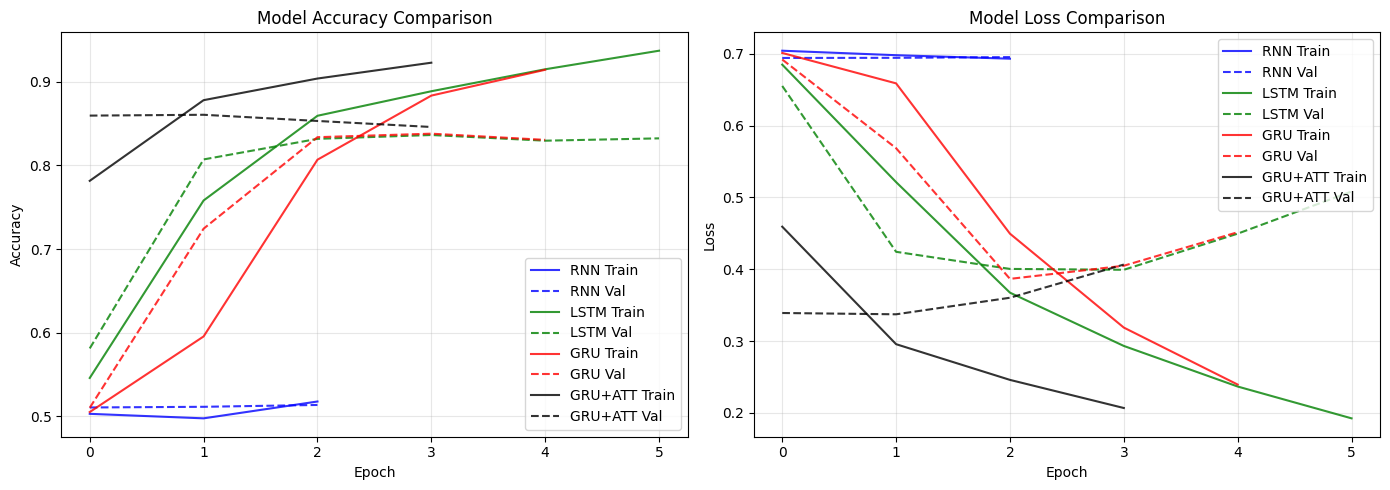

In [9]:
def plot_training_history(histories, model_names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = ['blue', 'green', 'red', 'black']
    
    for i, (history, name) in enumerate(zip(histories, model_names)):
        axes[0].plot(history.history['accuracy'], label=f'{name} Train', 
                    color=colors[i], linestyle='-', alpha=0.8)
        axes[0].plot(history.history['val_accuracy'], label=f'{name} Val',
                    color=colors[i], linestyle='--', alpha=0.8)
        
        axes[1].plot(history.history['loss'], label=f'{name} Train',
                    color=colors[i], linestyle='-', alpha=0.8)
        axes[1].plot(history.history['val_loss'], label=f'{name} Val',
                    color=colors[i], linestyle='--', alpha=0.8)
    
    axes[0].set_title('Model Accuracy Comparison')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_title('Model Loss Comparison')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history([rnn_history, lstm_history, gru_history, gru_attention_history], 
                     ['RNN', 'LSTM', 'GRU', 'GRU+ATT'])

    

In [10]:
tokenizer_path = "tokenizer.pkl"
import pickle

with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

rnn_model.save("rnn_model.h5")
lstm_model.save("lstm_model.h5")
gru_model.save("gru_model.h5")
gru_attention_model.save("gru_attention_model.h5")
